### IVOIRE Project — Vendor Scoring & Clustering
- Reads `seller_metrics` from PostgreSQL, computes a weighted composite score
- (`fct_vendor_score` /100) and a KMeans cluster assignment (`seller_clusters`)
per seller. Both are written back to PostgreSQL, linked by `seller_id`.

In [66]:
import pandas as pd
from sqlalchemy import create_engine
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

### 1. Connection & extraction

In [ ]:
engine = create_engine(
    "postgresql+psycopg2://postgres:@localhost:5432/Brazilian E-Commerce [IVOIRE]"
)
 
df = pd.read_sql("SELECT * FROM seller_metrics;", engine)
 
# INTERVAL -> pandas timedelta -> plain float (days)
df["avg_delay_days"] = df["avg_delay_days"].dt.total_seconds() / 86400
df["avg_delay_days"] = df["avg_delay_days"].fillna(df["avg_delay_days"].median())

### 2. Column groups & weights
- Grouped by dimension so the 40/40/20 weighting isn't skewed by column count
- (logistics has 3 raw columns, satisfaction and volume have 1 each).

In [68]:
logistics_cols = ["avg_delay_days", "pct_late_deliveries", "avg_freight_ratio"]
satisfaction_cols = ["avg_review_score"]
volume_cols = ["total_revenue"]

WEIGHTS = {
    "logistics": 0.40,
    "satisfaction": 0.40,
    "volume": 0.20,
}

### 3. Missing values
- Sellers with no reviews have `avg_review_score = NULL` (LEFT JOIN in SQL).
- Filled with the median neutral, not a penalty.

In [69]:
df["avg_review_score"] = df["avg_review_score"].fillna(df["avg_review_score"].median())

### 4. Normalization (Min-Max, 0–1)
- Min-max over z-score output is a bounded /100 score, no negatives to handle.

In [80]:
scaler = MinMaxScaler()
all_cols = logistics_cols + satisfaction_cols + volume_cols
 
df_normalized = df.copy()
df_normalized[all_cols] = scaler.fit_transform(df[all_cols])

### 5. Invert "lower is better" metrics
- Delay, late-delivery rate, and freight ratio are worse when higher.
- `1 - x` keeps "higher = better" consistent across every scored column.

In [71]:
cols_to_invert = ["avg_delay_days", "pct_late_deliveries", "avg_freight_ratio"]
for col in cols_to_invert:
    df_normalized[col] = 1 - df_normalized[col]

### 6. Sub-scores per dimension

In [72]:
df_normalized["logistics_subscore"] = df_normalized[logistics_cols].mean(axis=1)
df_normalized["satisfaction_subscore"] = df_normalized[satisfaction_cols].mean(axis=1)
df_normalized["volume_subscore"] = df_normalized[volume_cols].mean(axis=1)

### 7. Final weighted score (/100)

In [73]:
df_normalized["vendor_score"] = (
    df_normalized["logistics_subscore"] * WEIGHTS["logistics"]
    + df_normalized["satisfaction_subscore"] * WEIGHTS["satisfaction"]
    + df_normalized["volume_subscore"] * WEIGHTS["volume"]
) * 100

In [74]:
fct_vendor_score = df_normalized[[
    "seller_id",
    "logistics_subscore",
    "satisfaction_subscore",
    "volume_subscore",
    "vendor_score",
]].copy()

### 8. KMeans clustering
- Same normalized/inverted features as the score, kept separate (not combined)
- Groups sellers by overall profile rather than ranking them.

In [75]:
cluster_features = df_normalized[all_cols].copy()

#### Elbow method — pick K

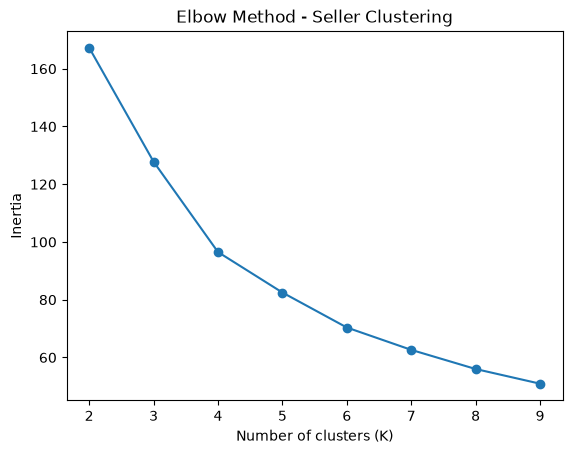

In [76]:
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_features)
    inertias.append(km.inertia_)
 
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Seller Clustering")
plt.show()

#### Final clustering
- `FINAL_K` set after inspecting the elbow plot above.

In [77]:
FINAL_K = 4
 
kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df_normalized["cluster_id"] = kmeans.fit_predict(cluster_features)
 
score = silhouette_score(cluster_features, df_normalized["cluster_id"])
print(f"Silhouette score for K={FINAL_K}: {score:.3f}")

Silhouette score for K=4: 0.344


### 8b. Cluster profiling
- Averages on the ORIGINAL raw-scale columns (real days, real %, real BRL)
- not the normalized/inverted ones, which don't map to real-world units.
- This is what the segment naming below is based on.

In [78]:
raw_profile = df.copy()
raw_profile["cluster_id"] = df_normalized["cluster_id"]
raw_profile["vendor_score"] = fct_vendor_score["vendor_score"]
 
profile_cols = logistics_cols + satisfaction_cols + volume_cols + ["vendor_score"]
 
cluster_profile = raw_profile.groupby("cluster_id")[profile_cols].mean().round(2)
cluster_profile["seller_count"] = raw_profile.groupby("cluster_id").size()
 
print("\nCluster profile (raw-scale averages):")
print(cluster_profile)
 
seller_clusters = df_normalized[["seller_id", "cluster_id"]].copy()


Cluster profile (raw-scale averages):
            avg_delay_days  pct_late_deliveries  avg_freight_ratio  \
cluster_id                                                           
0                   -13.04                 2.60               0.32   
1                     6.91                74.96               0.30   
2                   -12.68                 2.55               0.33   
3                   -11.27                 8.65               0.32   

            avg_review_score  total_revenue  vendor_score  seller_count  
cluster_id                                                               
0                       4.69        2613.55         72.64          1357  
1                       2.54        1147.03         40.30           100  
2                       1.69         999.41         42.43           267  
3                       3.81        8691.05         63.36          1371  


### 9. Re-import to PostgreSQL
- Two separate tables, linked by `seller_id`.

In [79]:
fct_vendor_score.to_sql("fct_vendor_score", engine, if_exists="replace", index=False)
seller_clusters.to_sql("seller_clusters", engine, if_exists="replace", index=False)
print("fct_vendor_score and seller_clusters written to PostgreSQL.")

fct_vendor_score and seller_clusters written to PostgreSQL.


### Seller segments

**Cluster 0 — Top Performers** *(1,357 sellers · score 72.64)*

Delivers ~13 days ahead of the estimate on average, with only a 2.6% late
rate the strongest logistics of any segment. Highest satisfaction (4.69/5).
Revenue is moderate (2,613), so this is a large group of small-to-mid
sellers who execute reliably rather than a high-volume elite.

**Cluster 1 — Chronic Underperformers** *(100 sellers · score 40.30)*

The clear outlier: delivers ~7 days late on average, with a 74.96% late
rate a different order of magnitude from every other segment. Lowest
revenue (1,147) and poor satisfaction (2.54/5). Primary at-risk segment
for platform-wide logistics KPIs.


**Cluster 2 — Reliable but Poorly Rated** *(267 sellers · score 42.43)*

Logistics nearly matches Cluster 0 (~13 days early, 2.55% late), yet
satisfaction is the lowest of all four segments (1.69/5) and revenue is
the smallest (999). Since delivery performance isn't the issue, the low
ratings likely stem from product quality, pricing, or another factor
outside this pipeline's logistics metrics worth a separate investigation.

**Cluster 3 — High-Volume Core** *(1,371 sellers · score 63.36)*

By far the highest revenue (8,691) of any segment, with solid if
slightly less sharp logistics (~11 days early, 8.65% late) and good
satisfaction (3.81/5). This is the platform's revenue backbone: strong
performance at scale, without being the top logistics/satisfaction segment.

Freight ratio (0.30–0.33 across all four) doesn't meaningfully differentiate
The segments logistics speed/reliability and satisfaction are the real
drivers of the clustering here, not shipping cost efficiency.